# Words that Fund — Kickstarter NLP Analysis
**Research Question:** How does linguistic framing in Kickstarter campaign descriptions affect the probability of crowdfunding success?

**Pipeline:**
1. Preprocessing
2. Exploratory Data Analysis (EDA)
3. Topic Modeling (LDA) con selezione automatica di K

---
## 0. Setup & Imports

In [1]:
!pip install gensim


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install pyLDAvis

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.6 MB 14.3 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 7.4 MB/s  0:00:00

   ------------- -------------------------- 1/3 [numexpr]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -------------------------- ------------- 2/3 [pyLDAvis]
   -----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\simon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\simon\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from itertools import chain

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel, Phrases
from gensim.models.phrases import Phraser

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from wordcloud import WordCloud

warnings.filterwarnings('ignore')
pyLDAvis.enable_notebook()

# Riproducibilità
SEED = 42
np.random.seed(SEED)

# Stile grafici
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Setup completato.')

Setup completato.


---
## 1. Caricamento Dati

In [6]:
DATA_PATH = 'Kickstarter_dataset_14-04.csv'

df = pd.read_csv(
    DATA_PATH,
    index_col=0,
    engine='python'
)

print(df.shape)
df.head()

(7354, 12)


,url,title,description,pledged,goal,currency,reached,status,description_processed,stemmed,lemmatized,category
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,48000.0,USD,148.172917,1,"['problem', 'much', 'entertainment', 'today', ...","['problem', 'much', 'entertain', 'today', 'pus...","['problem', 'much', 'entertainment', 'today', ...",Film & Video
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,61500.0,USD,106.208130,1,"['millions', 'american', 'college', 'students'...","['million', 'american', 'colleg', 'student', '...","['million', 'american', 'college', 'student', ...",Film & Video
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,8000.0,USD,5.775000,0,"['full', 'az', 'set', 'im', 'launching', 'set'...","['full', 'az', 'set', 'im', 'launch', 'set', '...","['full', 'az', 'set', 'im', 'launching', 'set'...",Film & Video
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,15000.0,USD,34.246667,0,"['sleepy', 'summer', 'afternoon', 'stared', 'v...","['sleepi', 'summer', 'afternoon', 'stare', 'vo...","['sleepy', 'summer', 'afternoon', 'stared', 'v...",Film & Video
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50000.0,USD,101.280000,0,"['48', 'hours', 'pledge', 'matching', 'amazing...","['48', 'hour', 'pledg', 'match', 'amaz', 'news...","['48', 'hour', 'pledge', 'matching', 'amazing'...",Film & Video


In [7]:
print('Valori nulli per colonna:')
print(df.isnull().sum())
print()
print('Distribuzione status (0=fallimento, 1=successo):')
print(df['status'].value_counts())
print()
print('Distribuzione categorie:')
print(df['category'].value_counts())

Valori nulli per colonna:
url                       0
title                    50
description               0
pledged                   0
goal                      0
currency                  0
reached                   0
status                    0
description_processed     0
stemmed                   0
lemmatized                0
category                  0
dtype: int64

Distribuzione status (0=fallimento, 1=successo):
status
1    3677
0    3677
Name: count, dtype: int64

Distribuzione categorie:
category
Film & Video    2011
Technology      1489
Games           1422
Music           1218
Publishing      1214
Name: count, dtype: int64


---
## 2. Preprocessing

Partiamo da `description_processed`, che contiene token già puliti (lowercase, stopwords base rimosse, punteggiatura rimossa).  
Applichiamo un secondo passaggio meticoloso:
- Parsing stringa → lista Python reale
- Rimozione token non alfabetici puri (simboli, punteggiatura residua, caratteri Unicode)
- Rimozione token con lunghezza ≤ 2 (rumorosi e privi di contenuto semantico)
- Rimozione stopwords English standard + stopwords **domain-specific Kickstarter** (parole onnipresenti per definizione della piattaforma, quindi non discriminanti)
- Lowercasing garantito

In [9]:
# ── Stopwords standard English ────────────────────────────────────────────────
STOPWORDS_EN = set([
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','are','was','were','be','been','being','have','has','had','do','does',
    'did','will','would','could','should','may','might','shall','can','need',
    'this','that','these','those','it','its','we','our','you','your','they',
    'their','he','his','she','her','what','which','who','whom','when','where',
    'why','how','all','each','every','both','few','more','most','other','some',
    'such','no','not','only','same','so','than','too','very','just','also',
    'about','after','before','between','into','through','during','above','below',
    'from','up','down','out','off','over','under','again','then','once','here',
    'there','any','my','me','him','her','us','them','if','by','as','am','get',
    'got','make','made','one','two','three','new','use','used','using','well',
    'now','like','even','back','still','way','take','time','know','think','want',
    'see','look','come','go','give','say','said','much','many','first','last',
    'long','great','little','own','right','big','high','different','small',
    'large','next','early','young','important','public','private','real','best',
    'free','let','put','set','keep','add','find','tell','ask','seem','feel',
    'try','leave','call','show','turn','start','actually','really','also',
    'always','never','often','already','around','without','within','along',
    'following','across','behind','beyond','plus','except','however','though',
    'although','since','while','because','until','unless','whether','where',
    'via','per','etc','able','need','make','making','take','taking','come',
    'coming','going','getting','having','being','doing','saying','looking',
    'including','including','based','part','full','lot','something','anything',
    'everything','nothing','someone','anyone','everyone','thing','things'
])

# ── Stopwords domain-specific Kickstarter ─────────────────────────────────────
# Parole onnipresenti nella piattaforma → non discriminanti tra campagne
STOPWORDS_KS = set([
    'kickstarter','campaign','pledge','pledges','pledged','goal','goals',
    'rewards','reward','backer','backers','backing','fund','funded','funding',
    'support','supports','supported','project','projects','production',
    'shipping','ship','ships','shipped','tier','tiers','stretch','stretchgoal',
    'contribute','contribution','contributions','contributor','contributors',
    'donate','donation','donations','donor','donors','amount','amounts',
    'price','prices','cost','costs','order','orders','available','availability',
    'limited','edition','exclusive','early','bird','launch','launching','launched'
])

ALL_STOPWORDS = STOPWORDS_EN | STOPWORDS_KS

print(f'Stopwords totali: {len(ALL_STOPWORDS)}')

Stopwords totali: 287


In [10]:
def preprocess_tokens(token_string: str, stopwords: set, min_len: int = 3) -> list:
    """
    Converte la stringa-lista di description_processed in una lista pulita di token.
    
    Filtri applicati:
    - Parsing AST della stringa
    - Lowercase
    - Solo token alfabetici puri (niente numeri, simboli, Unicode non-alpha)
    - Lunghezza >= min_len (default 3)
    - Rimozione stopwords (EN + domain-specific KS)
    """
    try:
        tokens = ast.literal_eval(token_string)
    except Exception:
        return []
    
    cleaned = [
        lemmatizer.lemmatize(t.lower())
        for t in tokens
        if isinstance(t, str)
        and t.isalpha()              # solo caratteri alfabetici
        and len(t) >= min_len        # lunghezza minima
        and t.lower() not in stopwords  # non è una stopword
    ]
    return cleaned


# Applica a tutto il dataset
df['tokens'] = df['description_processed'].apply(
    lambda x: preprocess_tokens(x, ALL_STOPWORDS, min_len=3)
)

# Statistiche sul corpus
df['n_tokens'] = df['tokens'].apply(len)

print('Preprocessing completato.')
print(f'Token totali nel corpus: {df["n_tokens"].sum():,}')
print(f'Token medi per documento: {df["n_tokens"].mean():.1f}')
print(f'Token mediani per documento: {df["n_tokens"].median():.1f}')
print(f'Documenti con < 10 token: {(df["n_tokens"] < 10).sum()}')
print()
print('Esempio token (riga 0):')
print(df['tokens'].iloc[0][:15])

Preprocessing completato.
Token totali nel corpus: 3,339,749
Token medi per documento: 454.1
Token mediani per documento: 347.0
Documenti con < 10 token: 0

Esempio token (riga 0):
['problem', 'entertainment', 'today', 'push', 'unholy', 'agenda', 'story', 'consume', 'guard', 'desensitize', 'sin', 'convince', 'adopt', 'untrue', 'idea']


In [11]:
from collections import Counter

all_tokens = [t for toks in df['tokens'] for t in toks]
print(Counter(all_tokens).most_common(20))

[('film', 19383), ('game', 18577), ('book', 14022), ('story', 13178), ('world', 13147), ('help', 12715), ('year', 11826), ('work', 11546), ('life', 11152), ('music', 10063), ('play', 8770), ('people', 8739), ('design', 8630), ('art', 8345), ('experience', 8240), ('love', 7762), ('card', 7555), ('team', 7069), ('sound', 7029), ('video', 6955)]


In [12]:
# Rimuoviamo documenti con troppo pochi token (< 10) — non informativi per LDA # non ce ne sono
n_before = len(df)
df = df[df['n_tokens'] >= 10].reset_index(drop=True)
print(f'Documenti rimossi per n_token < 10: {n_before - len(df)}')
print(f'Corpus finale: {len(df)} documenti')

Documenti rimossi per n_token < 10: 0
Corpus finale: 7354 documenti


---
## 3. EDA — Exploratory Data Analysis

### 3.1 Distribuzione lunghezza descrizioni

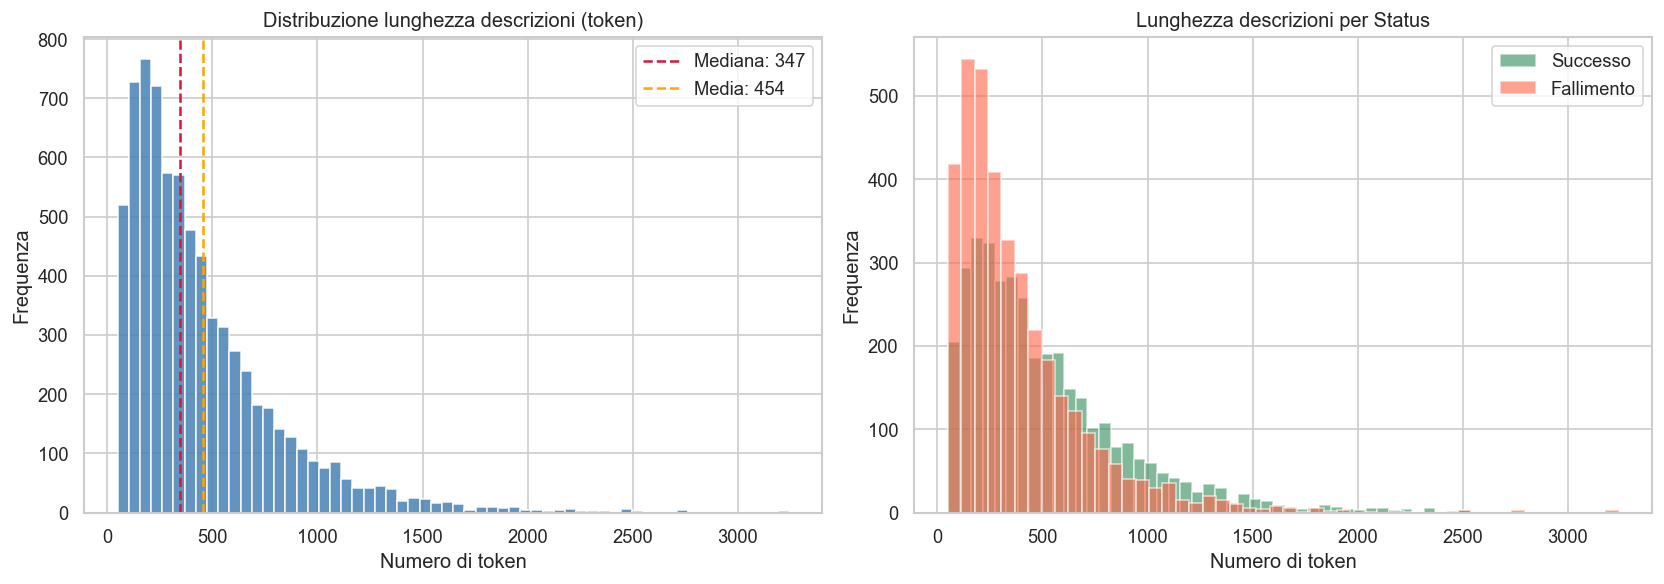

Statistiche per status:
         count   mean    std   min    25%    50%    75%     max
status                                                         
0       3677.0  389.2  330.1  49.0  169.0  294.0  501.0  3242.0
1       3677.0  519.1  395.5  52.0  236.0  412.0  687.0  2811.0
 it means that proects with longer description are most likely to be founded ( both mean and median) than projects with shorter description:IMP CORRELATION, NOT CAUSATION


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione globale
axes[0].hist(df['n_tokens'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['n_tokens'].median(), color='crimson', linestyle='--', linewidth=1.5, label=f'Mediana: {df["n_tokens"].median():.0f}')
axes[0].axvline(df['n_tokens'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Media: {df["n_tokens"].mean():.0f}')
axes[0].set_title('Distribuzione lunghezza descrizioni (token)')
axes[0].set_xlabel('Numero di token')
axes[0].set_ylabel('Frequenza')
axes[0].legend()

# Per status
for status, label, color in [(1, 'Successo', 'seagreen'), (0, 'Fallimento', 'tomato')]:
    subset = df[df['status'] == status]['n_tokens']
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='white')

axes[1].set_title('Lunghezza descrizioni per Status')
axes[1].set_xlabel('Numero di token')
axes[1].set_ylabel('Frequenza')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_token_length.png', bbox_inches='tight')
plt.show()

print('Statistiche per status:')
print(df.groupby('status')['n_tokens'].describe().round(1))
print(" it means that proects with longer description are most likely to be founded \
( both mean and median) than projects with shorter description:\
IMP CORRELATION, NOT CAUSATION")

### 3.2 Distribuzione lunghezza per categoria

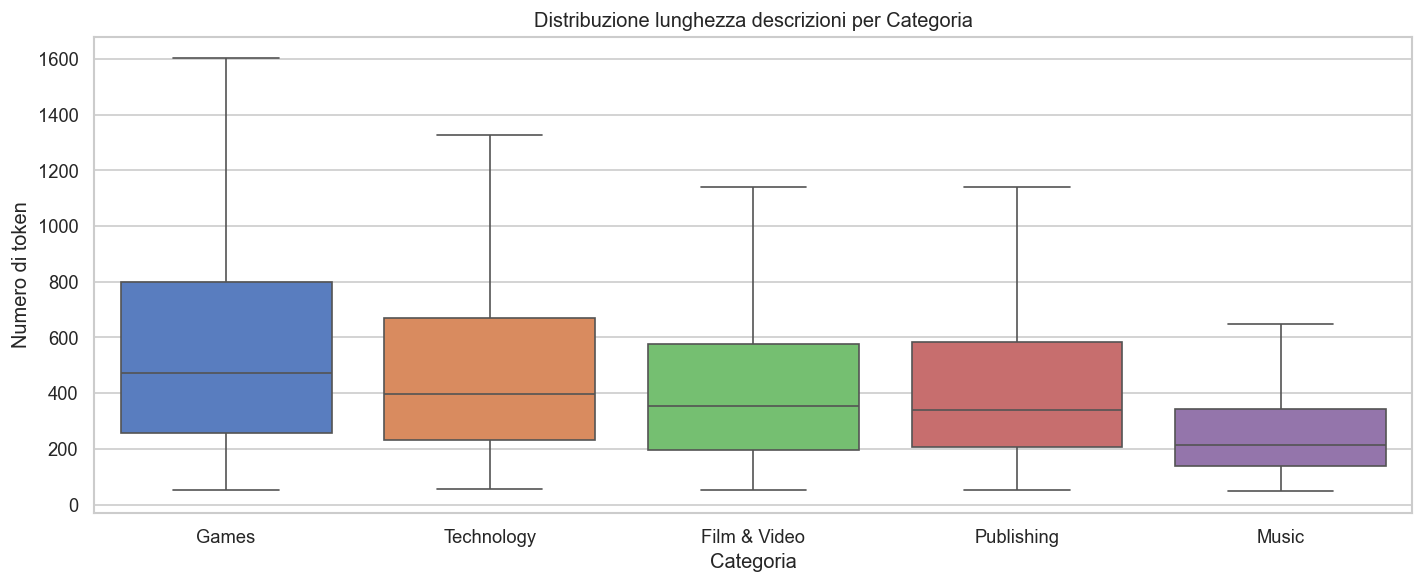

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

category_order = df.groupby('category')['n_tokens'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df, x='category', y='n_tokens',
    order=category_order,
    palette='muted', ax=ax,
    showfliers=False
)
ax.set_title('Distribuzione lunghezza descrizioni per Categoria')
ax.set_xlabel('Categoria')
ax.set_ylabel('Numero di token')
plt.tight_layout()
plt.savefig('eda_token_by_category.png', bbox_inches='tight')
plt.show()

### 3.3 Distribuzione `reached` (% goal raggiunto)

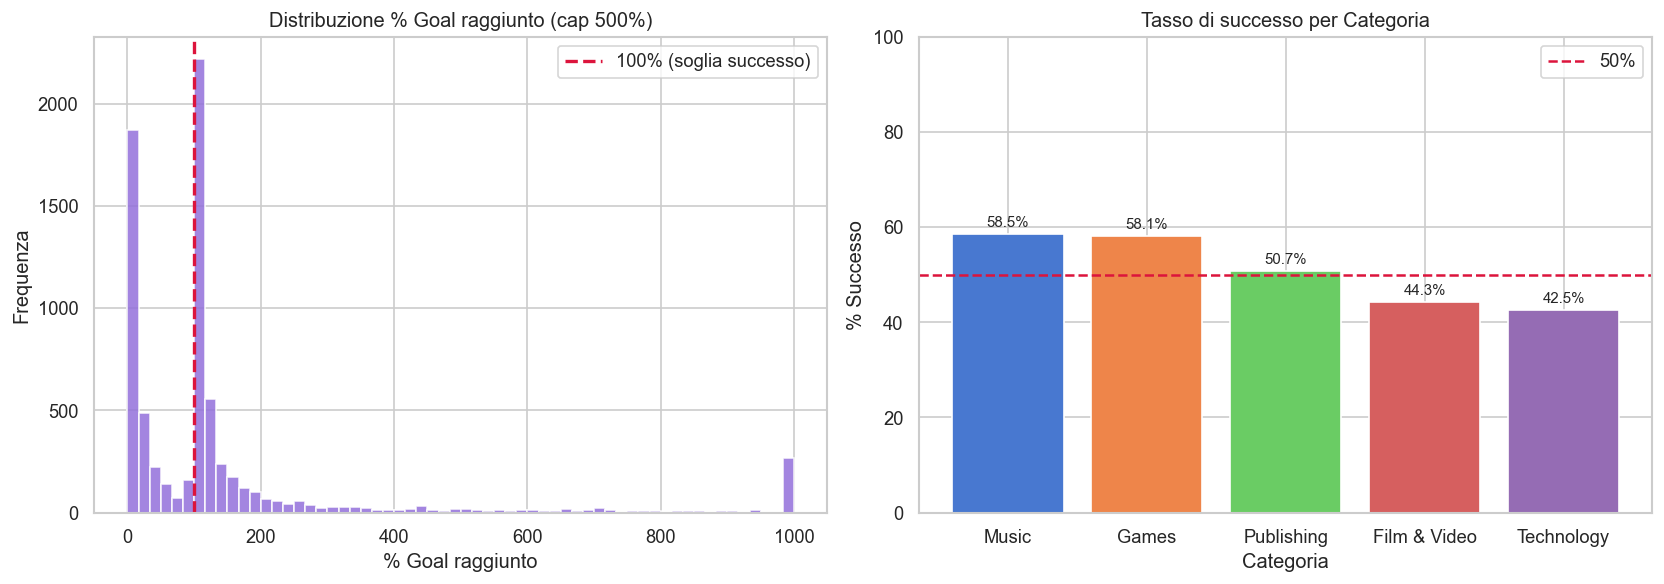

Success rate per categoria:
category
Music           58.5
Games           58.1
Publishing      50.7
Film & Video    44.3
Technology      42.5
Name: status, dtype: float64
 very important, it shows that, despite of everything else,succes does depend also on the category itself


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuzione globale (capped a 500% per leggibilità)
reached_capped = df['reached'].clip(upper=1000)
axes[0].hist(reached_capped, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].axvline(100, color='crimson', linestyle='--', linewidth=2, label='100% (soglia successo)')
axes[0].set_title('Distribuzione % Goal raggiunto (cap 500%)')
axes[0].set_xlabel('% Goal raggiunto')
axes[0].set_ylabel('Frequenza')
axes[0].legend()

# Per categoria
cat_success = df.groupby('category')['status'].mean().sort_values(ascending=False)
bars = axes[1].bar(cat_success.index, cat_success.values * 100,
                   color=sns.color_palette('muted', len(cat_success)),
                   edgecolor='white')
axes[1].axhline(50, color='crimson', linestyle='--', linewidth=1.5, label='50%')
axes[1].set_title('Tasso di successo per Categoria')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('% Successo')
axes[1].set_ylim(0, 100)
axes[1].legend()
for bar, val in zip(bars, cat_success.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_reached_success.png', bbox_inches='tight')
plt.show()

print('Success rate per categoria:')
print((df.groupby('category')['status'].mean() * 100).round(1).sort_values(ascending=False))
print(' very important, it shows that, despite of everything else,\
succes does depend also on the category itself')

### 3.4 Top 30 parole — Successo vs Fallimento - Approccio sbagliato ma ok tenere

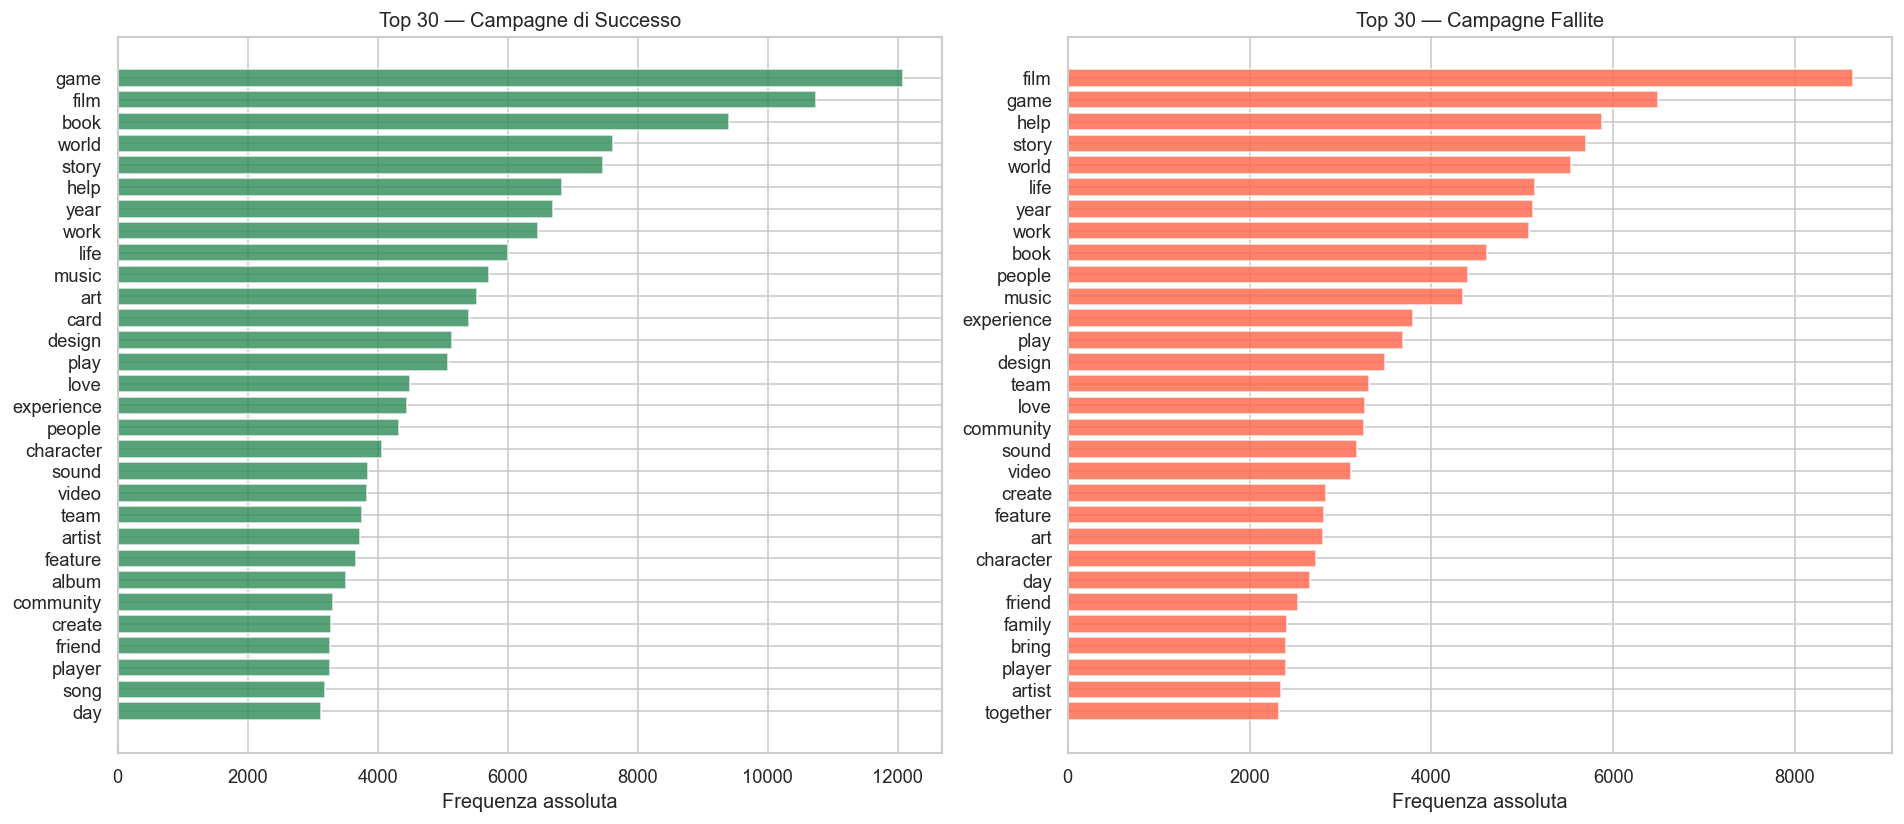

poco infromativo, essendo i progetti 50/50 1/0 ci sta che la stessa parola (sul numero assoluto di quante volte apparequindi ad esempio topic cinema con film che appre molto spesso sia meta founded e meta non foundedApproccio sbagliato, le frequenze assolute non discriminano successo/fallimento


In [19]:
def top_words(token_series, n=30):
    all_tokens = list(chain.from_iterable(token_series))
    return Counter(all_tokens).most_common(n)

top_success = top_words(df[df['status'] == 1]['tokens'])
top_fail    = top_words(df[df['status'] == 0]['tokens'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, top, title, color in [
    (axes[0], top_success, 'Top 30 — Campagne di Successo', 'seagreen'),
    (axes[1], top_fail,    'Top 30 — Campagne Fallite',     'tomato')
]:
    words, counts = zip(*top)
    y_pos = range(len(words))
    ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Frequenza assoluta')

plt.tight_layout()
plt.savefig('eda_top_words.png', bbox_inches='tight')
plt.show()
print ("poco infromativo, essendo i progetti 50/50 1/0 ci sta che la stessa parola (sul numero assoluto di quante volte appare\
quindi ad esempio topic cinema con film che appre molto spesso sia meta founded e meta non founded\
Approccio sbagliato, le frequenze assolute non discriminano successo/fallimento")

### 3.5 Parole distintive — Log-odds ratio tra classi

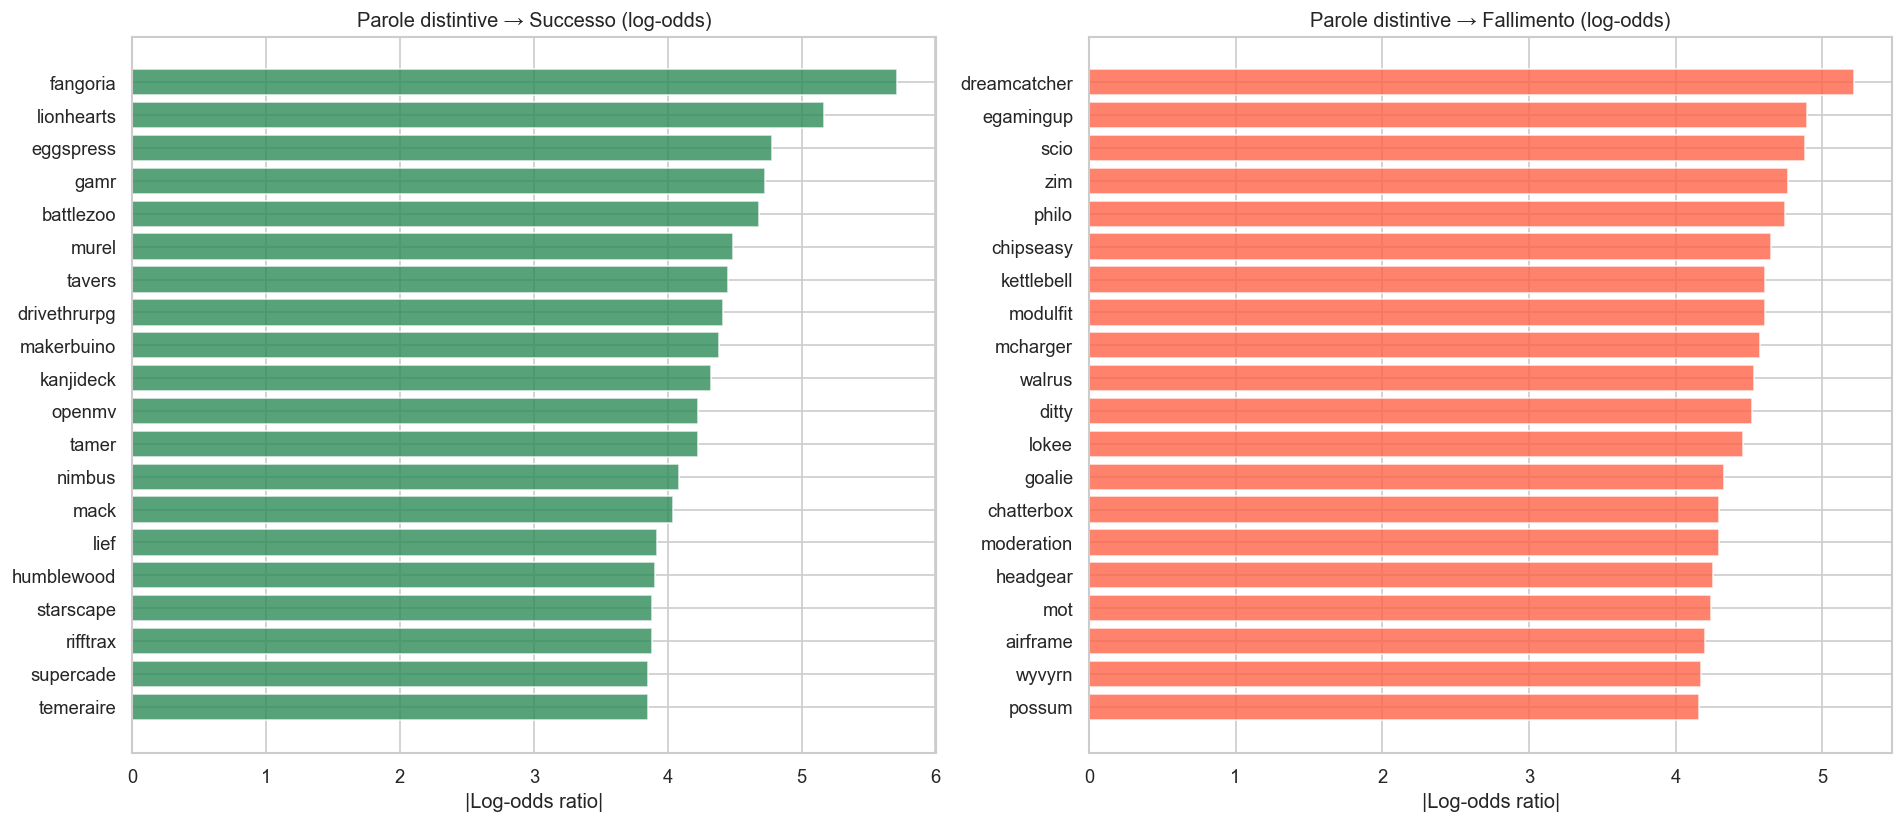

 questa analisi corretta, abbiamo p(w|success) e p(w|fail)potremmo anche aumentare conteggio, mi sembra la parte davveor informativaquali parole caratterizzano una classe rispetto all'altraProblema: i risultati in questo caso sono ancora molto sensibili a parole molto rare/idiosincratiche ( es charizard)


In [22]:
# Log-odds ratio: parole più associate a successo vs fallimento
def class_word_freq(token_series):
    counts = Counter(chain.from_iterable(token_series))
    total = sum(counts.values())
    return {w: c / total for w, c in counts.items()}

freq_succ = class_word_freq(df[df['status'] == 1]['tokens'])
freq_fail = class_word_freq(df[df['status'] == 0]['tokens'])

all_words = set(freq_succ.keys()) | set(freq_fail.keys())
eps = 1e-6  # smoothing

log_odds = {
    w: np.log((freq_succ.get(w, eps)) / (freq_fail.get(w, eps)))
    for w in all_words
    if (freq_succ.get(w, 0) + freq_fail.get(w, 0)) > 1e-5  # solo parole abbastanza frequenti
}

sorted_lo = sorted(log_odds.items(), key=lambda x: x[1])
top_succ_distinctive = sorted_lo[-20:][::-1]
top_fail_distinctive = sorted_lo[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in [
    (axes[0], top_succ_distinctive, 'Parole distintive → Successo (log-odds)', 'seagreen'),
    (axes[1], top_fail_distinctive, 'Parole distintive → Fallimento (log-odds)', 'tomato')
]:
    words, scores = zip(*data)
    y_pos = range(len(words))
    ax.barh(y_pos, [abs(s) for s in scores], color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('|Log-odds ratio|')

plt.tight_layout()
plt.savefig('eda_log_odds.png', bbox_inches='tight')
plt.show()
print(" questa analisi corretta, abbiamo p(w|success) e p(w|fail)\
potremmo anche aumentare conteggio, mi sembra la parte davveor informativa\
quali parole caratterizzano una classe rispetto all'altra\
Problema: i risultati in questo caso sono ancora molto sensibili a parole molto rare/idiosincratiche ( es charizard)")

### problema fino ad ora è che non abbiamo fatto tf idf quindi parole molto specifiche di n singolo progetto ( non infromative) potrebbero essere associata ad alta prob di funding, ma non è significativo , da adesso faciamo tf idf 

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

df['text_for_tfidf'] = df['tokens'].apply(lambda toks: ' '.join(toks))

TOP_N = 10

vectorizer = TfidfVectorizer(
    min_df=50,
    max_df=0.7,
    ngram_range=(2,2),   # ← QUESTO È IL CAMBIO, passiamo da uni grammi a bi grammi, con uni grammi, poco significativo, no conclusioni traibili
    max_features=5000
)

X_tfidf = vectorizer.fit_transform(df['text_for_tfidf'])

feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names, index=df.index)
tfidf_df['status'] = df['status'].values

mean_tfidf_by_status = tfidf_df.groupby('status').mean()

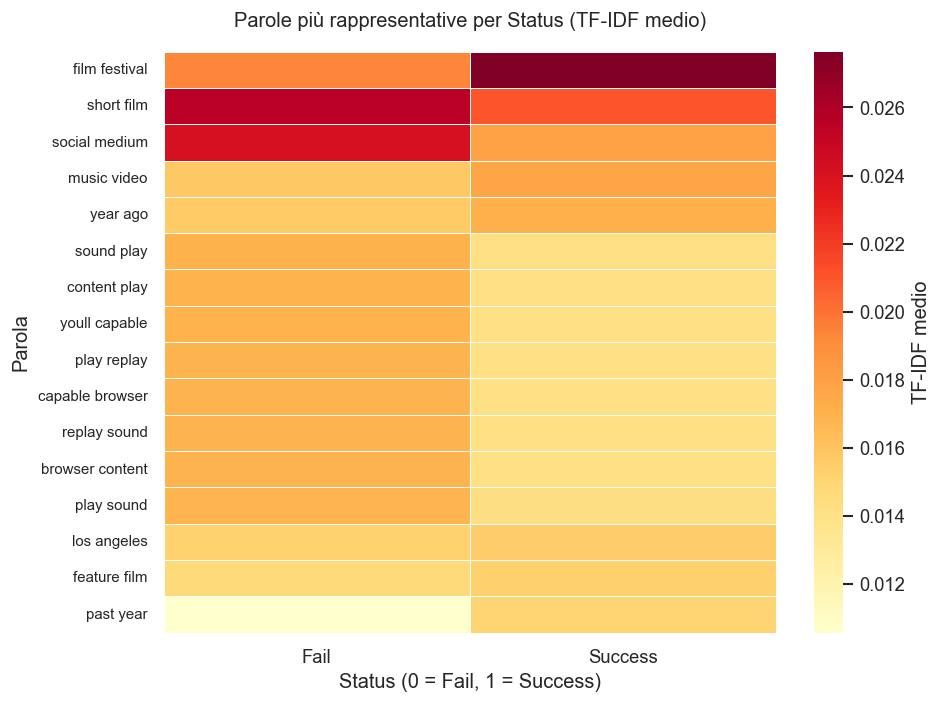

 “Il confronto delle medie TF-IDF tra successo e fallimento non evidenziadifferenze marcate, suggerendo che il linguaggio medio delle descrizioni è simile tra le due classi. Questo indica la necessità di utilizzare metodi più sensibili alle differenze locali o modelli supervisionati.”


In [21]:
selected_words = set()

# seleziono le parole più rappresentative per ciascuno status
for status in mean_tfidf_by_status.index:
    top_words_status = mean_tfidf_by_status.loc[status].sort_values(ascending=False).head(TOP_N)
    selected_words.update(top_words_status.index)

selected_words = list(selected_words)

# costruisco matrice parole × status
heatmap_data = mean_tfidf_by_status[selected_words].T

# ordino le parole per leggibilità
heatmap_data['max_score'] = heatmap_data.max(axis=1)
heatmap_data = heatmap_data.sort_values('max_score', ascending=False).drop(columns='max_score')

# plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'TF-IDF medio'}
)

ax.set_title('Parole più rappresentative per Status (TF-IDF medio)', pad=15)
ax.set_xlabel('Status (0 = Fail, 1 = Success)')
ax.set_ylabel('Parola')

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(['Fail', 'Success'])

plt.tight_layout()
plt.savefig('eda_heatmap_status_tfidf.png', bbox_inches='tight')
plt.show()
print(' “Il confronto delle medie TF-IDF tra successo e fallimento non evidenzia\
differenze marcate, suggerendo che il linguaggio medio delle descrizioni è simile \
tra le due classi. Questo indica la necessità di utilizzare metodi più sensibili \
alle differenze locali o modelli supervisionati.”')

ValueError: not enough values to unpack (expected 2, got 0)

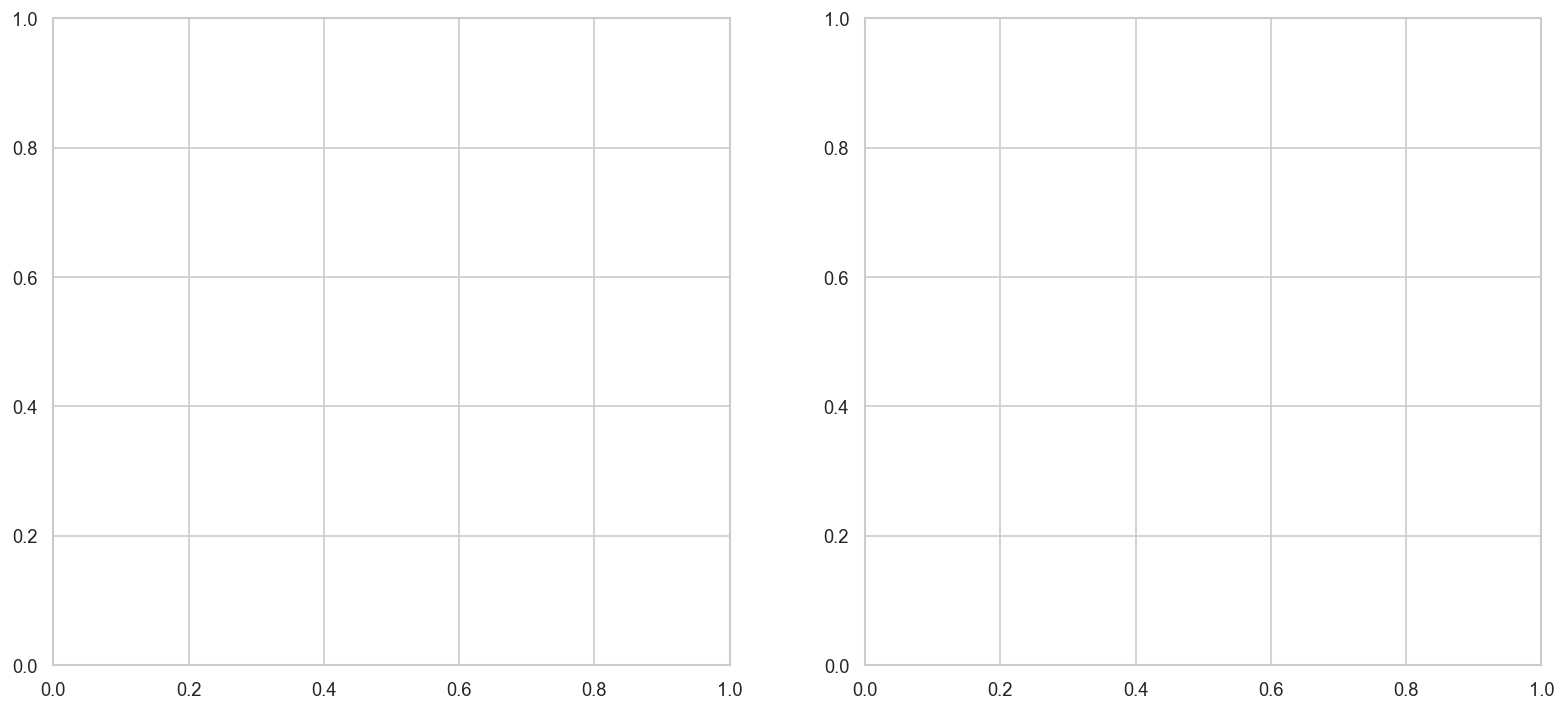

In [51]:
# vocabolario filtrato TF-IDF - valido nel caso di uni grammi, non in caso di bi grammi 
vocab = set(feature_names)

def class_word_freq_filtered(token_series, vocab):
    counts = Counter(
        w for toks in token_series for w in toks if w in vocab
    )
    total = sum(counts.values())
    return {w: c / total for w, c in counts.items()}

freq_succ = class_word_freq_filtered(df[df['status'] == 1]['tokens'], vocab)
freq_fail = class_word_freq_filtered(df[df['status'] == 0]['tokens'], vocab)

all_words = set(freq_succ) | set(freq_fail)
eps = 1e-6

log_odds = {
    w: np.log((freq_succ.get(w, eps)) / (freq_fail.get(w, eps)))
    for w in all_words
}

sorted_lo = sorted(log_odds.items(), key=lambda x: x[1])

top_succ = sorted_lo[-20:][::-1]
top_fail = sorted_lo[:20]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, data, title, color in [
    (axes[0], top_succ, 'Parole → Successo (TF-IDF + log-odds)', 'seagreen'),
    (axes[1], top_fail, 'Parole → Fallimento (TF-IDF + log-odds)', 'tomato')
]:
    words, scores = zip(*data)
    y_pos = range(len(words))
    ax.barh(y_pos, [abs(s) for s in scores], color=color, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title)

plt.tight_layout()
plt.show()

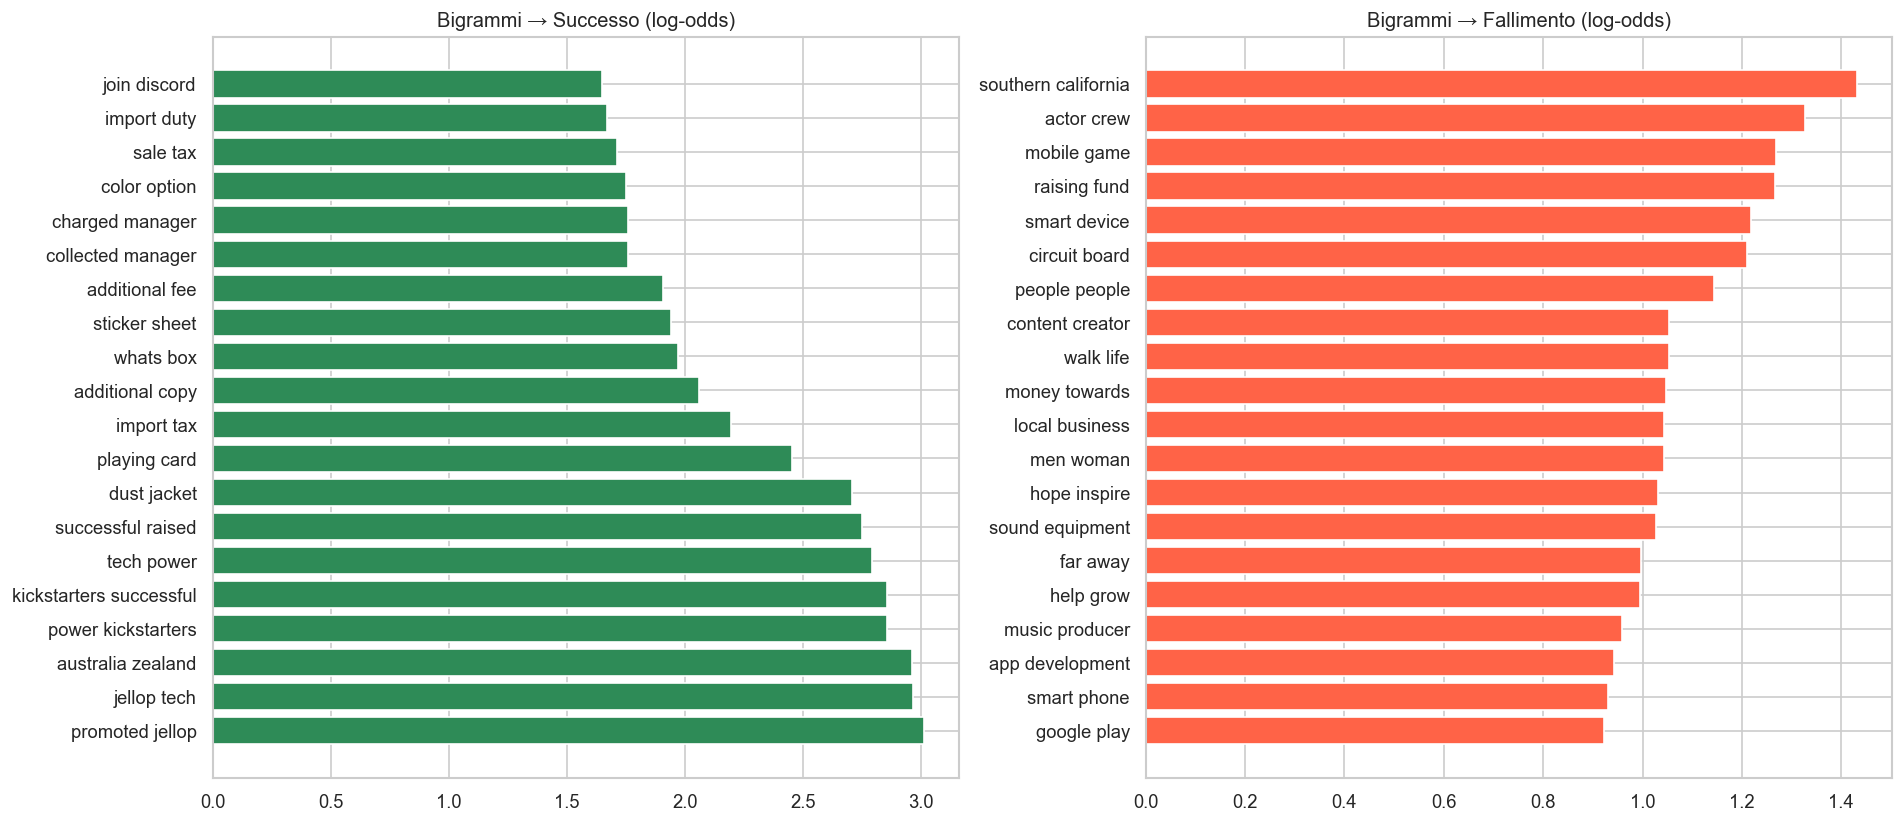

In [52]:
from sklearn.feature_extraction.text import CountVectorizer

TOP_N = 20
eps = 1e-6

# Bigrammi: meglio usare conteggi, non TF-IDF, per il log-odds
count_vectorizer = CountVectorizer(
    min_df=50,
    max_df=0.7,
    ngram_range=(2, 2),
    max_features=5000
)

X_counts = count_vectorizer.fit_transform(df['text_for_tfidf'])
bigram_names = count_vectorizer.get_feature_names_out()

counts_df = pd.DataFrame(X_counts.toarray(), columns=bigram_names, index=df.index)
counts_df['status'] = df['status'].values
succ_counts = counts_df[counts_df['status'] == 1].drop(columns='status').sum(axis=0)
fail_counts = counts_df[counts_df['status'] == 0].drop(columns='status').sum(axis=0)

# tengo solo bigrammi presenti almeno una volta nel totale
valid = (succ_counts + fail_counts) > 0
succ_counts = succ_counts[valid]
fail_counts = fail_counts[valid]

p_succ = succ_counts / succ_counts.sum()
p_fail = fail_counts / fail_counts.sum()

log_odds = np.log((p_succ + eps) / (p_fail + eps)).sort_values()

top_fail = log_odds.head(TOP_N)
top_succ = log_odds.tail(TOP_N)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(range(len(top_succ)), top_succ.values, color='seagreen', edgecolor='white')
axes[0].set_yticks(range(len(top_succ)))
axes[0].set_yticklabels(top_succ.index)
axes[0].invert_yaxis()
axes[0].set_title('Bigrammi → Successo (log-odds)')

axes[1].barh(range(len(top_fail)), abs(top_fail.values), color='tomato', edgecolor='white')
axes[1].set_yticks(range(len(top_fail)))
axes[1].set_yticklabels(top_fail.index)
axes[1].invert_yaxis()
axes[1].set_title('Bigrammi → Fallimento (log-odds)')

plt.tight_layout()
plt.show()

### blocco intra - categoria uni grammi


=== Categoria: Film & Video ===


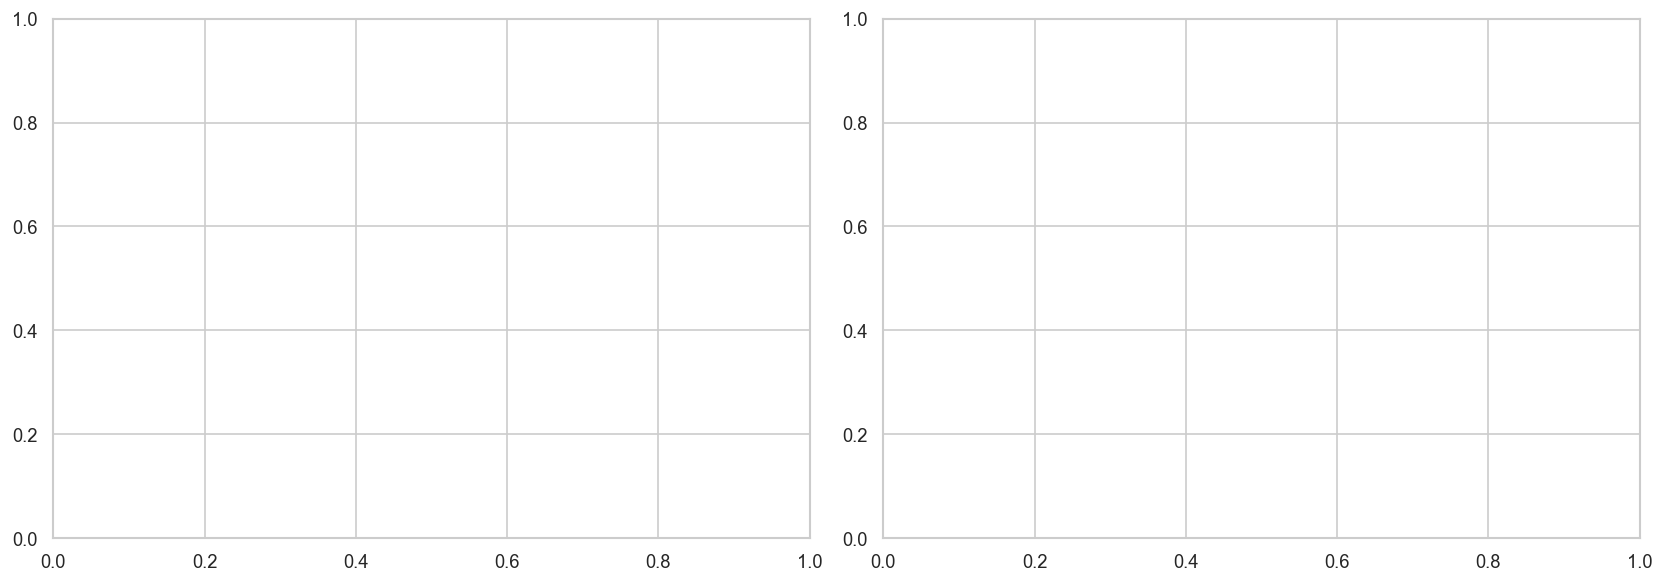


=== Categoria: Games ===


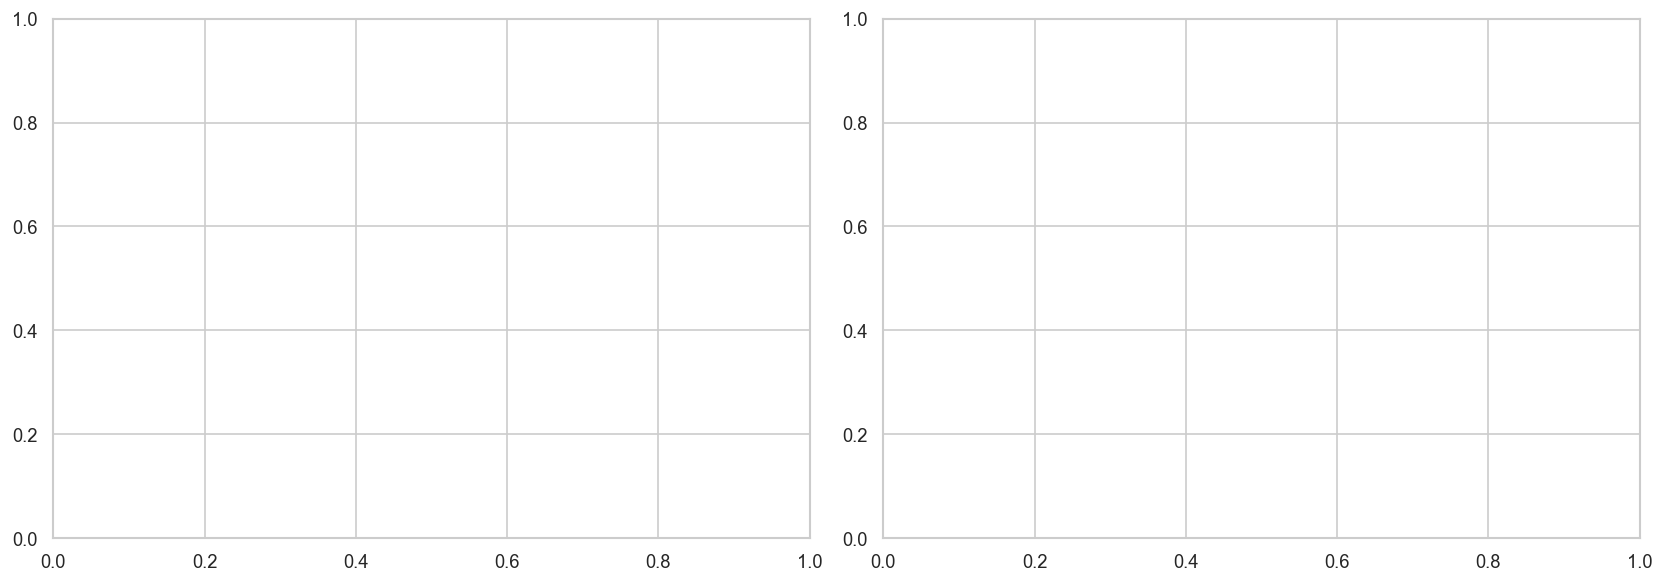


=== Categoria: Music ===


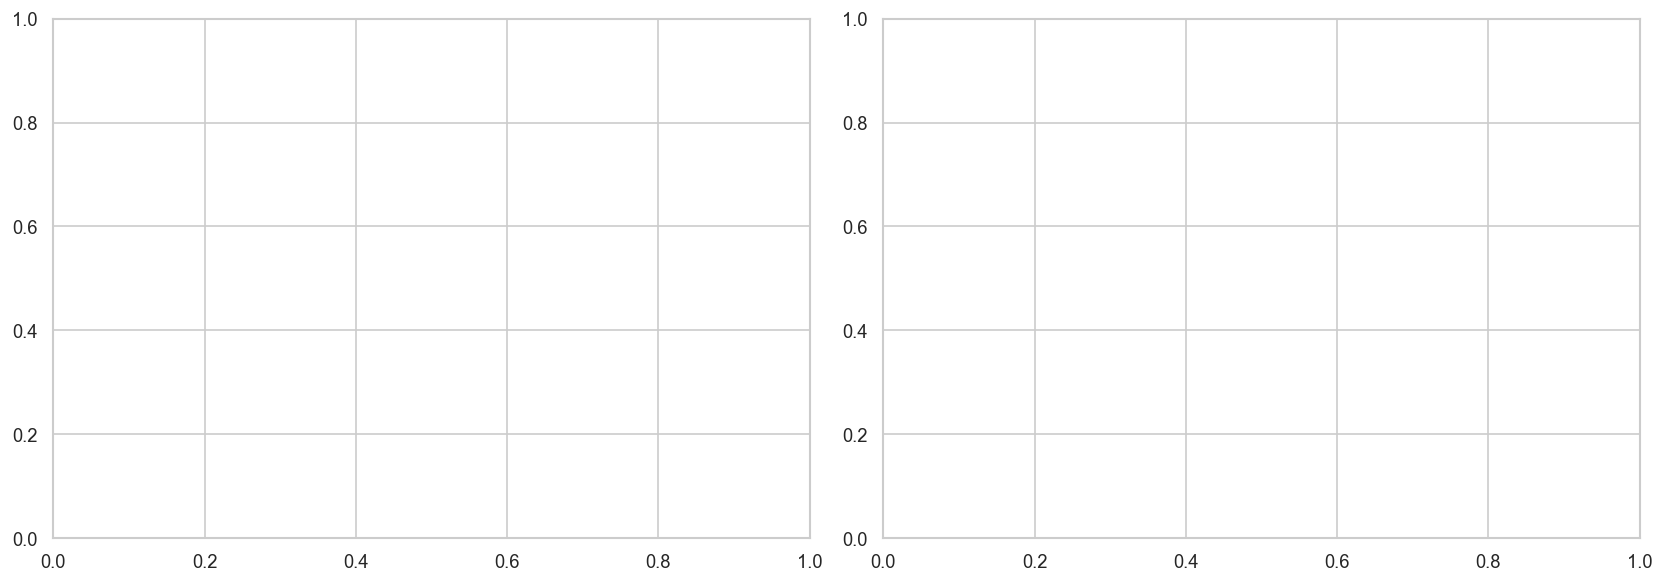


=== Categoria: Publishing ===


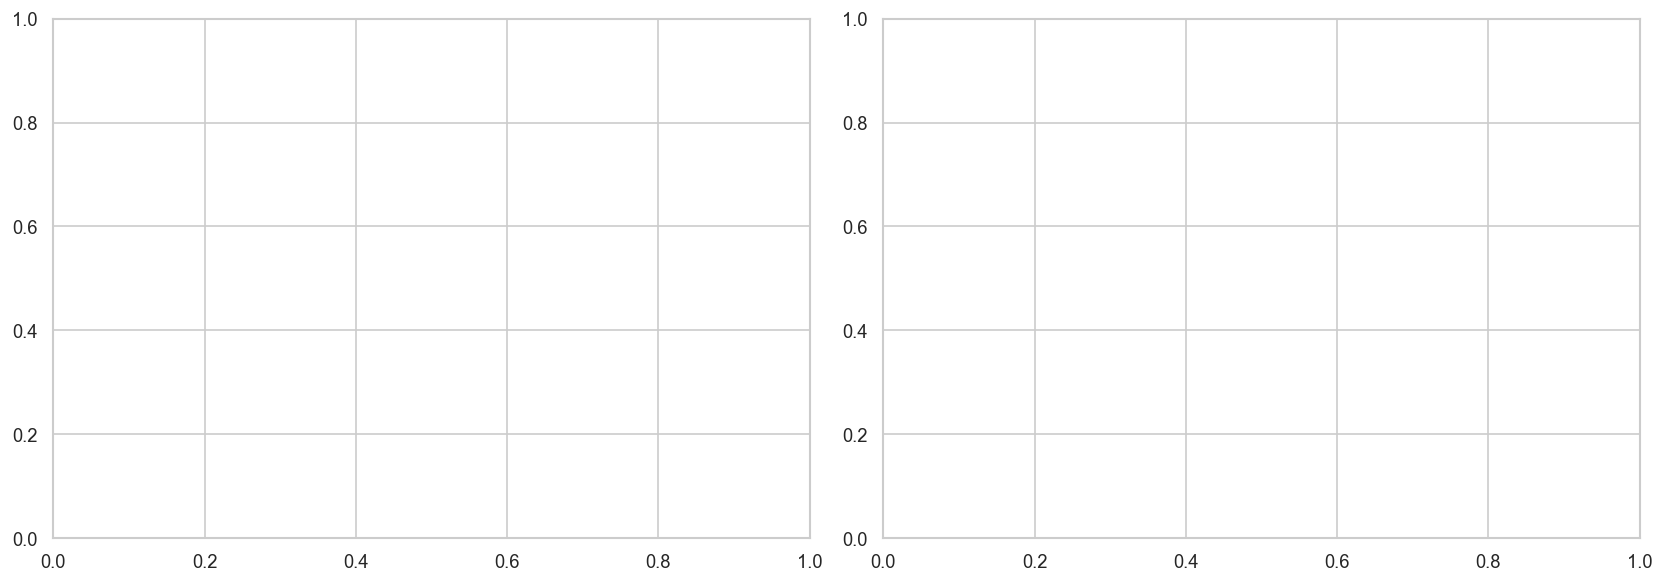


=== Categoria: Technology ===


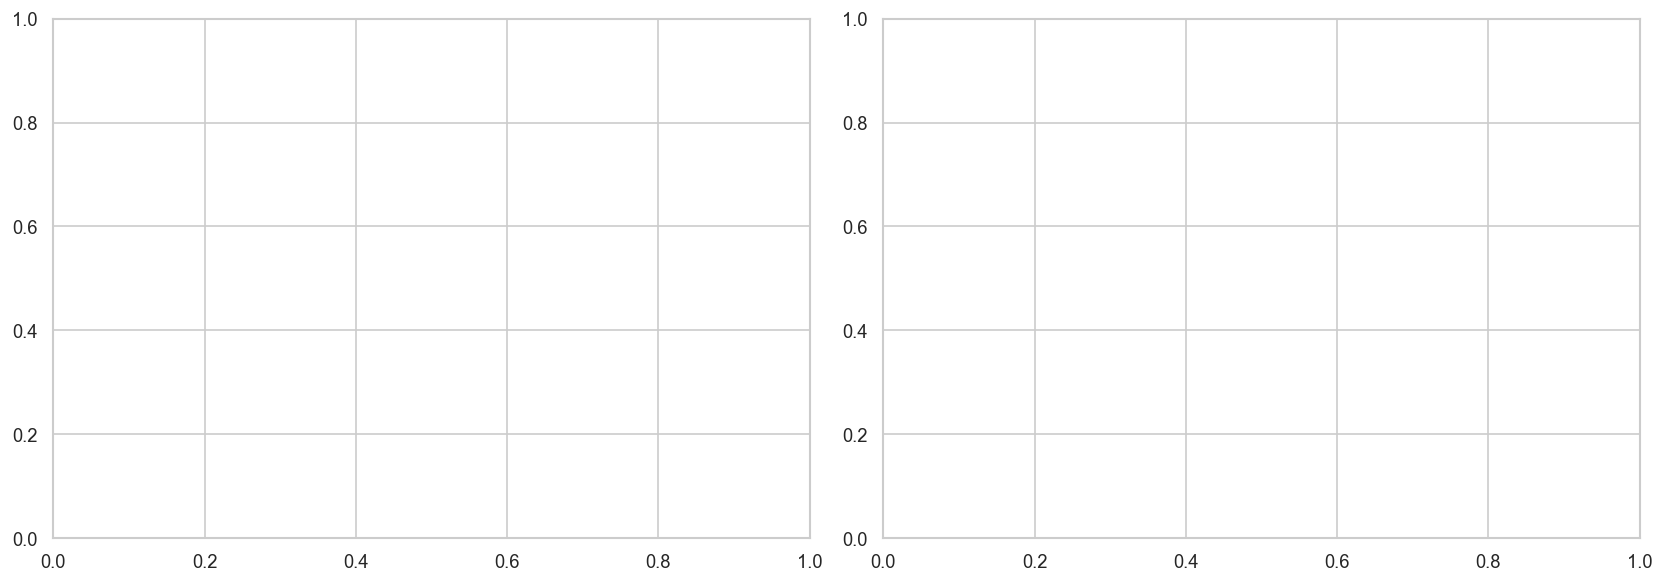

conclusione: lavorare su uni grammi è poco significativo,prossimo step procediamo su n grams


In [53]:
TOP_N = 10

categories = df['category'].unique()

for cat in categories:
    print(f'\n=== Categoria: {cat} ===')
    
    df_cat = df[df['category'] == cat]
    
    # salta categorie troppo piccole
    if df_cat['status'].nunique() < 2:
        print('Salto (solo una classe)')
        continue
    
    # frequenze filtrate sul vocabolario TF-IDF
    freq_succ = class_word_freq_filtered(
        df_cat[df_cat['status'] == 1]['tokens'], vocab
    )
    freq_fail = class_word_freq_filtered(
        df_cat[df_cat['status'] == 0]['tokens'], vocab
    )
    
    all_words = set(freq_succ) | set(freq_fail)
    eps = 1e-6

    log_odds = {
        w: np.log((freq_succ.get(w, eps)) / (freq_fail.get(w, eps)))
        for w in all_words
    }

    sorted_lo = sorted(log_odds.items(), key=lambda x: x[1])

    top_succ = sorted_lo[-TOP_N:][::-1]
    top_fail = sorted_lo[:TOP_N]

    # plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, title, color in [
        (axes[0], top_succ, f'{cat} → Successo', 'seagreen'),
        (axes[1], top_fail, f'{cat} → Fallimento', 'tomato')
    ]:
        if len(data) == 0:
            continue
        words, scores = zip(*data)
        y_pos = range(len(words))
        ax.barh(y_pos, [abs(s) for s in scores], color=color, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words)
        ax.invert_yaxis()
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

print('conclusione: lavorare su uni grammi è poco significativo,\
prossimo step procediamo su n grams')
      

### blocco intra - categoria bi grammi


=== Categoria: Film & Video ===


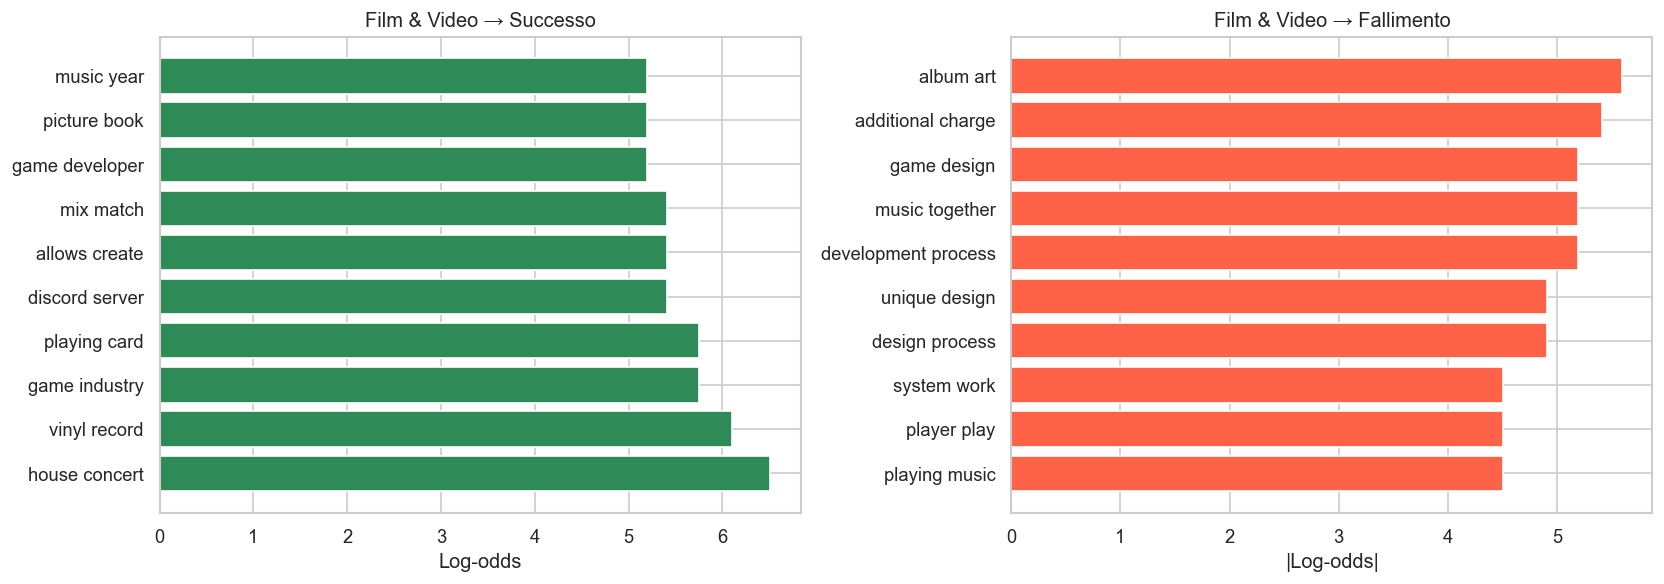


=== Categoria: Games ===


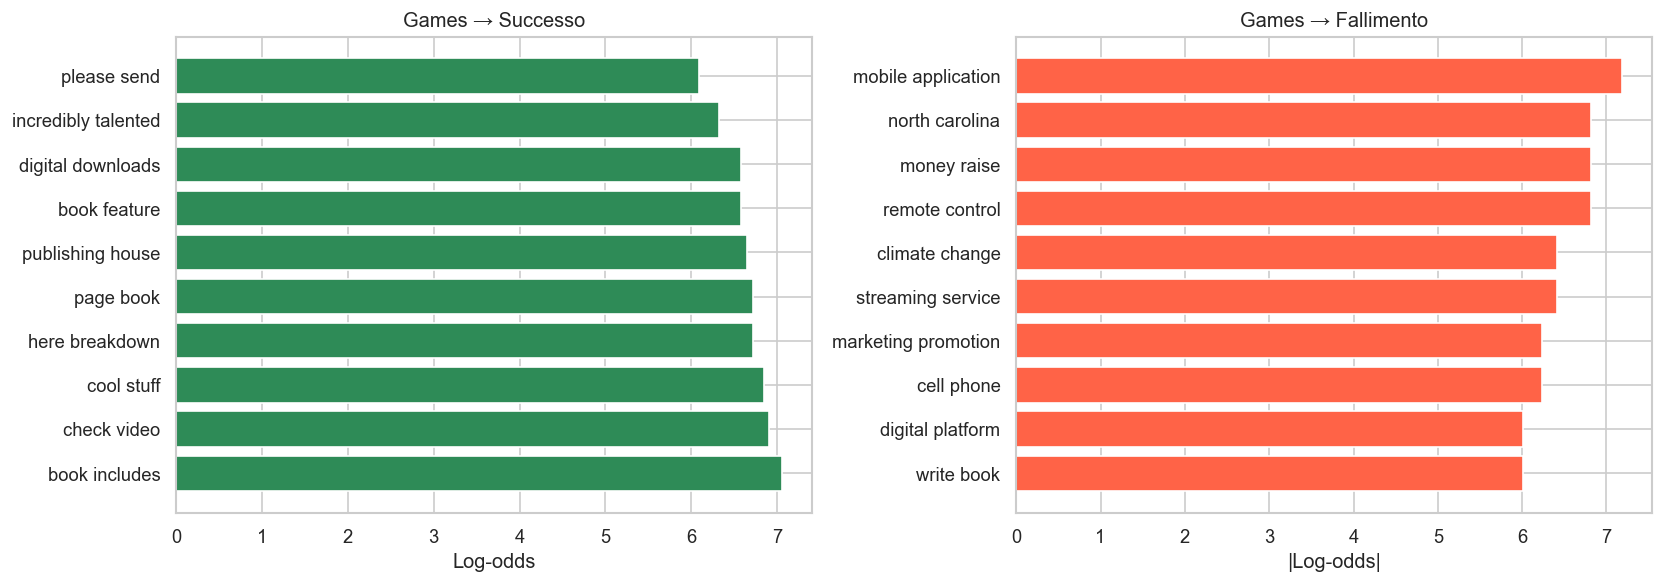


=== Categoria: Music ===


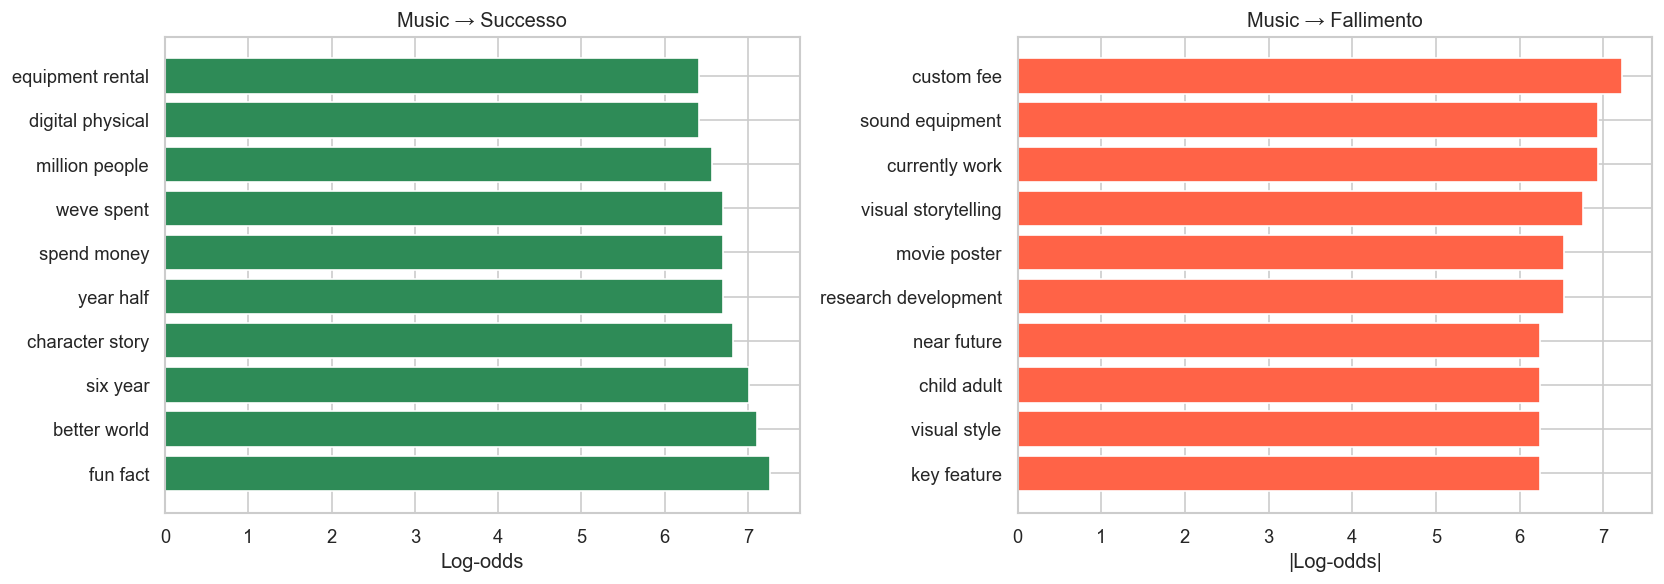


=== Categoria: Publishing ===


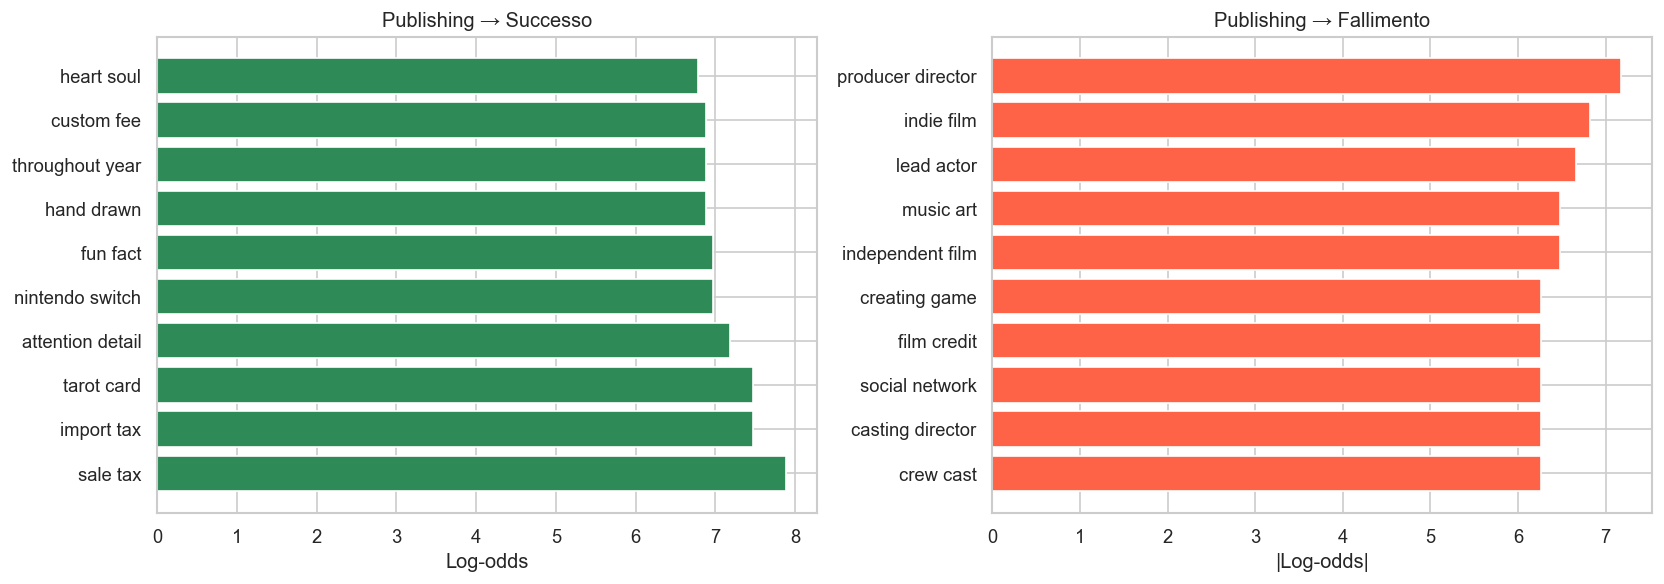


=== Categoria: Technology ===


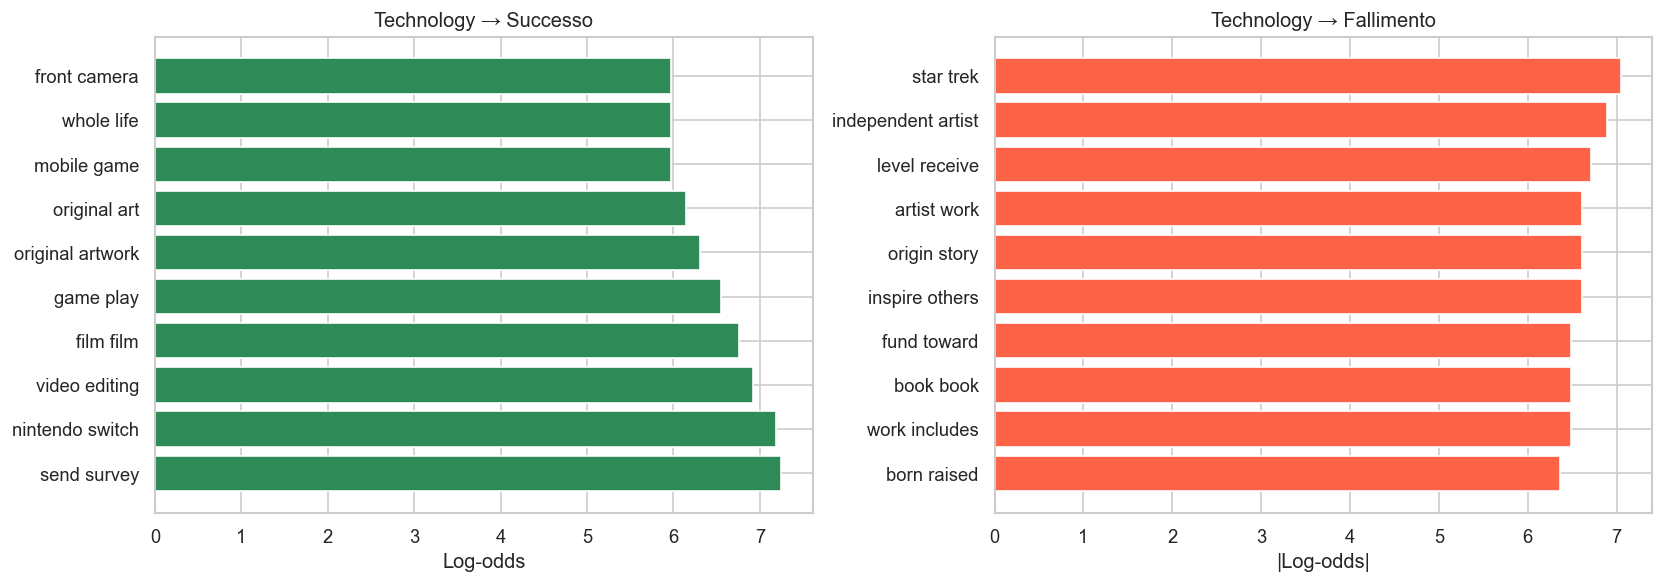

In [55]:
TOP_N = 10
eps = 1e-6

# Aggiungo categoria alla matrice dei bigrammi
counts_df['category'] = df['category'].values

for cat in counts_df['category'].unique():
    print(f'\n=== Categoria: {cat} ===')
    
    sub = counts_df[counts_df['category'] == cat]
    
    # controllo minimo: devono esserci entrambe le classi
    if sub['status'].nunique() < 2:
        print('Salto: una sola classe presente')
        continue
    
    X_sub = sub.drop(columns=['status', 'category'])
    
    succ_counts = X_sub[sub['status'] == 1].sum(axis=0)
    fail_counts = X_sub[sub['status'] == 0].sum(axis=0)
    
    # tengo solo bigrammi presenti almeno una volta nel totale della categoria
    valid = (succ_counts + fail_counts) > 0
    succ_counts = succ_counts[valid]
    fail_counts = fail_counts[valid]
    
    if len(succ_counts) == 0:
        print('Salto: nessun bigramma valido')
        continue
    
    p_succ = succ_counts / succ_counts.sum()
    p_fail = fail_counts / fail_counts.sum()
    
    log_odds_cat = np.log((p_succ + eps) / (p_fail + eps)).sort_values()
    
    top_fail = log_odds_cat.head(TOP_N)
    top_succ = log_odds_cat.tail(TOP_N)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Successo
    axes[0].barh(range(len(top_succ)), top_succ.values, color='seagreen', edgecolor='white')
    axes[0].set_yticks(range(len(top_succ)))
    axes[0].set_yticklabels(top_succ.index)
    axes[0].invert_yaxis()
    axes[0].set_title(f'{cat} → Successo')
    axes[0].set_xlabel('Log-odds')
    
    # Fallimento
    axes[1].barh(range(len(top_fail)), abs(top_fail.values), color='tomato', edgecolor='white')
    axes[1].set_yticks(range(len(top_fail)))
    axes[1].set_yticklabels(top_fail.index)
    axes[1].invert_yaxis()
    axes[1].set_title(f'{cat} → Fallimento')
    axes[1].set_xlabel('|Log-odds|')
    
    plt.tight_layout()
    plt.show()

### conclusione principale:
- o proviamo a cambiare i parametri ma li ho gia fine tunati abbastanza, quindi non so
- di base non vi è un'associazione vera e propria tra parola ( o parole ) e successo / fallimento, se ci aspettiamo magari che parole come limited edition o early access o high quality facciano da discriminante in questo caso, non lo vediamo.
- risposta di chat:
    1) molto rumore “semantico debole”

Esempi:

fun fact, better world, heart soul
cool stuff, please send
front camera, mobile game

parole plausibili, ma:
→ non sono pattern forti
→ non sono generalizzabili

2. Molto ancora “contesto progetto”

Esempi:

nintendo switch, mobile game
actor crew, indie film

NON è linguaggio → è tipo di progetto

3. Nessun pattern consistente cross-categoria

Non vedi cose tipo:

“limited edition” sempre positivo
“early access” sempre positivo
“high quality” sempre positivo

il successo NON è spiegato in modo forte dal linguaggio della descrizione (almeno a livello lessicale)


Kickstarter non è:

copywriting puro
marketing puro

È:

prodotto
idea
visual
community

Il testo aiuta, ma non è il driver dominante

### da qui in poi, non ho piu toccato

---
## 4. Preparazione Corpus per LDA

### 4.1 Bigrams & Trigrams
Usiamo `gensim.models.Phrases` per rilevare automaticamente collocazioni statisticamente significative (es. `social_media`, `video_game`, `open_source`).  
Parametri chiave:
- `min_count`: frequenza minima del bigram nel corpus
- `threshold`: soglia del punteggio (più alta = bigram più selettivi)

In [ ]:
corpus_tokens = df['tokens'].tolist()

# Bigrams
bigram_model = Phrases(corpus_tokens, min_count=10, threshold=50)
bigram_phraser = Phraser(bigram_model)

# Trigrams (applicati sui bigram)
trigram_model = Phrases(bigram_phraser[corpus_tokens], min_count=5, threshold=50)
trigram_phraser = Phraser(trigram_model)

# Applica al corpus
corpus_ngrams = [trigram_phraser[bigram_phraser[doc]] for doc in corpus_tokens]

# Esempi di bigram/trigram trovati
sample_ngrams = [t for t in corpus_ngrams[0] if '_' in t]
print(f'Esempio ngrams nel doc 0: {sample_ngrams[:10]}')

# Conta bigram totali trovati
all_ngrams = [t for doc in corpus_ngrams for t in doc if '_' in t]
print(f'\nBigram/trigram totali nel corpus: {len(all_ngrams):,}')
print(f'Bigram/trigram unici: {len(set(all_ngrams)):,}')
print(f'\nTop 20 bigram più frequenti:')
for ng, cnt in Counter(all_ngrams).most_common(20):
    print(f'  {ng}: {cnt}')

### 4.2 Dizionario e Corpus Bag-of-Words

In [ ]:
# Dizionario Gensim
dictionary = corpora.Dictionary(corpus_ngrams)

print(f'Dimensione dizionario prima del filtering: {len(dictionary):,} termini')

# Filtering estremi:
# - no_below: termini che appaiono in meno di N documenti (rumore, hapax)
# - no_above: termini che appaiono in più del X% dei documenti (troppo generici)
# - keep_n: tieni solo i top N termini per frequenza (opzionale)
dictionary.filter_extremes(no_below=15, no_above=0.5, keep_n=50000)

print(f'Dimensione dizionario dopo il filtering: {len(dictionary):,} termini')

# Corpus Bag-of-Words
bow_corpus = [dictionary.doc2bow(doc) for doc in corpus_ngrams]

print(f'\nCorpus BoW costruito: {len(bow_corpus)} documenti')
print(f'Esempio (doc 0, prime 5 coppie): {bow_corpus[0][:5]}')

---
## 5. Selezione K — Numero Ottimale di Topic

Usiamo tre criteri:
1. **Coherence Score C_v** — massimizzare
2. **Perplexity** — minimizzare  
3. **Elbow Method** sul coherence

Per ogni K eseguiamo **più run** con seed diversi per stabilizzare le stime (LDA è stocastico).

In [ ]:
K_RANGE  = range(3, 21)   # K da 3 a 20
N_RUNS   = 3              # run per K (bilanciamento qualità/tempo)
N_PASSES = 10             # passaggi LDA per run

results = []  # lista di dict con metriche per ogni (K, run)

print(f'Valutazione K in {list(K_RANGE)} con {N_RUNS} run ciascuno...')
print(f'Totale modelli da addestrare: {len(list(K_RANGE)) * N_RUNS}')
print()

for k in K_RANGE:
    coh_scores = []
    perp_scores = []
    
    for run in range(N_RUNS):
        lda = LdaModel(
            corpus=bow_corpus,
            id2word=dictionary,
            num_topics=k,
            passes=N_PASSES,
            random_state=SEED + run * 100,
            alpha='auto',       # prior asimmetrico sui topic
            eta='auto',         # prior asimmetrico sulle parole
            per_word_topics=True
        )
        
        # Coherence C_v
        coh_model = CoherenceModel(
            model=lda,
            texts=corpus_ngrams,
            dictionary=dictionary,
            coherence='c_v'
        )
        coh = coh_model.get_coherence()
        
        # Perplexity (log-perplexity dal modello)
        perp = lda.log_perplexity(bow_corpus)
        
        coh_scores.append(coh)
        perp_scores.append(perp)
    
    mean_coh  = np.mean(coh_scores)
    std_coh   = np.std(coh_scores)
    mean_perp = np.mean(perp_scores)
    
    results.append({
        'k': k,
        'coherence_mean': mean_coh,
        'coherence_std':  std_coh,
        'perplexity_mean': mean_perp
    })
    
    print(f'K={k:2d} | Coherence: {mean_coh:.4f} ± {std_coh:.4f} | Perplexity: {mean_perp:.4f}')

results_df = pd.DataFrame(results)
print('\nValutazione completata.')

### 5.1 Visualizzazione Coherence & Perplexity

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coherence
ax = axes[0]
ax.plot(results_df['k'], results_df['coherence_mean'], 'o-', color='steelblue', linewidth=2, markersize=6)
ax.fill_between(
    results_df['k'],
    results_df['coherence_mean'] - results_df['coherence_std'],
    results_df['coherence_mean'] + results_df['coherence_std'],
    alpha=0.2, color='steelblue', label='±1 std'
)
best_k_coh = results_df.loc[results_df['coherence_mean'].idxmax(), 'k']
ax.axvline(best_k_coh, color='crimson', linestyle='--', linewidth=1.5, label=f'Best K={best_k_coh}')
ax.set_title('Coherence Score (C_v) per K')
ax.set_xlabel('Numero di Topic (K)')
ax.set_ylabel('Coherence Score')
ax.legend()
ax.set_xticks(list(K_RANGE))

# Perplexity
ax = axes[1]
ax.plot(results_df['k'], results_df['perplexity_mean'], 's-', color='darkorange', linewidth=2, markersize=6)
best_k_perp = results_df.loc[results_df['perplexity_mean'].idxmin(), 'k']
ax.axvline(best_k_perp, color='crimson', linestyle='--', linewidth=1.5, label=f'Best K={best_k_perp}')
ax.set_title('Log-Perplexity per K (minimizzare)')
ax.set_xlabel('Numero di Topic (K)')
ax.set_ylabel('Log-Perplexity')
ax.legend()
ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig('lda_k_selection.png', bbox_inches='tight')
plt.show()

print(f'K ottimale per Coherence: {best_k_coh}')
print(f'K ottimale per Perplexity: {best_k_perp}')

### 5.2 Elbow Method — Variazione Marginale del Coherence

In [ ]:
# Derivata prima del coherence (differenza primo ordine)
coh_values = results_df['coherence_mean'].values
delta_coh   = np.diff(coh_values)   # guadagno marginale aggiungendo 1 topic
k_values    = results_df['k'].values

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Curva coherence con elbow
ax = axes[0]
ax.plot(k_values, coh_values, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.set_title('Coherence Score — Elbow Method')
ax.set_xlabel('K')
ax.set_ylabel('Coherence (C_v)')
ax.set_xticks(list(K_RANGE))

# Variazione marginale
ax = axes[1]
ax.bar(k_values[1:], delta_coh, color=[
    'seagreen' if d > 0 else 'tomato' for d in delta_coh
], edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Variazione marginale Coherence (ΔC_v)')
ax.set_xlabel('K')
ax.set_ylabel('ΔCoherence')
ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig('lda_elbow.png', bbox_inches='tight')
plt.show()

# Suggerimento automatico del gomito
# Punto dove il guadagno marginale scende sotto una soglia (10% del max guadagno)
max_gain = delta_coh.max()
threshold_elbow = max_gain * 0.1
elbow_candidates = [k_values[i+1] for i, d in enumerate(delta_coh) if d < threshold_elbow]
elbow_k = elbow_candidates[0] if elbow_candidates else best_k_coh

print(f'Elbow suggerito (primo K con ΔC_v < 10% del max): K={elbow_k}')
print(f'Best K per Coherence assoluta: K={best_k_coh}')
print()
print('→ K finale scelto per LDA:', max(elbow_k, best_k_coh))

---
## 6. LDA Finale

In [ ]:
# Seleziona K finale (modifica manualmente se preferisci un valore specifico)
K_FINAL = best_k_coh  # oppure: elbow_k, o un valore custom

print(f'Training LDA finale con K={K_FINAL}, 20 passes...')

lda_final = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=K_FINAL,
    passes=20,
    random_state=SEED,
    alpha='auto',
    eta='auto',
    per_word_topics=True,
    chunksize=2000
)

# Coherence finale
coh_final = CoherenceModel(
    model=lda_final,
    texts=corpus_ngrams,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print(f'\nLDA finale addestrato.')
print(f'Coherence C_v finale: {coh_final:.4f}')

### 6.1 Top parole per topic

In [ ]:
TOP_WORDS_PER_TOPIC = 12

print(f'=== TOP {TOP_WORDS_PER_TOPIC} PAROLE PER TOPIC ===')
print()

topic_words = {}
for i in range(K_FINAL):
    words = lda_final.show_topic(i, topn=TOP_WORDS_PER_TOPIC)
    topic_words[i] = words
    word_str = ', '.join([f'{w} ({p:.3f})' for w, p in words])
    print(f'Topic {i:2d}: {word_str}')

### 6.2 Visualizzazione topic — Barre probabilità

In [ ]:
n_cols = 3
n_rows = int(np.ceil(K_FINAL / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

colors = cm.tab20(np.linspace(0, 1, K_FINAL))

for i in range(K_FINAL):
    words, probs = zip(*topic_words[i])
    ax = axes[i]
    ax.barh(range(len(words)), probs, color=colors[i], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'Topic {i}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Probabilità', fontsize=8)

# Nascondi subplot vuoti
for j in range(K_FINAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'LDA — Top {TOP_WORDS_PER_TOPIC} parole per topic (K={K_FINAL})', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('lda_topics_bars.png', bbox_inches='tight')
plt.show()

### 6.3 Distribuzione topic per documento

In [ ]:
# Calcola distribuzione topic per ogni documento
def get_doc_topic_vector(bow, model, k):
    topic_dist = dict(model.get_document_topics(bow, minimum_probability=0))
    return [topic_dist.get(i, 0.0) for i in range(k)]

topic_matrix = np.array([
    get_doc_topic_vector(bow, lda_final, K_FINAL)
    for bow in bow_corpus
])

# Topic dominante per documento
df['dominant_topic'] = topic_matrix.argmax(axis=1)
df['dominant_topic_prob'] = topic_matrix.max(axis=1)

# Aggiungi colonne topic al df
for i in range(K_FINAL):
    df[f'topic_{i}'] = topic_matrix[:, i]

print('Topic matrix shape:', topic_matrix.shape)
print()
print('Distribuzione topic dominante:')
print(df['dominant_topic'].value_counts().sort_index())

### 6.4 Topic per Categoria e Status

In [ ]:
topic_cols = [f'topic_{i}' for i in range(K_FINAL)]

# Media probabilità topic per categoria
topic_by_category = df.groupby('category')[topic_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    topic_by_category.T,
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Probabilità media'}
)
ax.set_title('Distribuzione media dei Topic per Categoria', pad=15)
ax.set_xlabel('Categoria')
ax.set_ylabel('Topic')
plt.tight_layout()
plt.savefig('lda_topics_by_category.png', bbox_inches='tight')
plt.show()

In [ ]:
# Media probabilità topic per status
topic_by_status = df.groupby('status')[topic_cols].mean()
topic_by_status.index = ['Fallimento (0)', 'Successo (1)']

# Differenza successo - fallimento per ogni topic
topic_diff = (topic_by_status.loc['Successo (1)'] - topic_by_status.loc['Fallimento (0)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(
    topic_by_status,
    annot=True, fmt='.4f', cmap='coolwarm',
    linewidths=0.3, ax=axes[0],
    cbar_kws={'label': 'Probabilità media'}
)
axes[0].set_title('Probabilità media topic per Status', pad=15)

# Differenza
colors_diff = ['seagreen' if d > 0 else 'tomato' for d in topic_diff]
axes[1].bar(range(K_FINAL), topic_diff.values, color=colors_diff, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(range(K_FINAL))
axes[1].set_xticklabels([f'T{i}' for i in range(K_FINAL)])
axes[1].set_title('Differenza probabilità topic\n(Successo − Fallimento)', pad=15)
axes[1].set_xlabel('Topic')
axes[1].set_ylabel('Δ Probabilità')

plt.tight_layout()
plt.savefig('lda_topics_by_status.png', bbox_inches='tight')
plt.show()

print('Topic più associati al SUCCESSO (Δ positivo):')
for t, d in topic_diff.sort_values(ascending=False).head(5).items():
    words = ', '.join([w for w, _ in topic_words[int(t.split('_')[1])][:6]])
    print(f'  {t}: Δ={d:.4f} | [{words}]')

print()
print('Topic più associati al FALLIMENTO (Δ negativo):')
for t, d in topic_diff.sort_values(ascending=True).head(5).items():
    words = ', '.join([w for w, _ in topic_words[int(t.split('_')[1])][:6]])
    print(f'  {t}: Δ={d:.4f} | [{words}]')

### 6.5 Visualizzazione interattiva — pyLDAvis

In [ ]:
vis = gensimvis.prepare(lda_final, bow_corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(vis, 'lda_interactive.html')
print('Visualizzazione interattiva salvata in: lda_interactive.html')
vis

---
## 7. Salvataggio risultati

In [ ]:
# Salva dataframe arricchito con topic
df.to_csv('kickstarter_with_topics.csv', index=False)
print('Dataset con topic salvato: kickstarter_with_topics.csv')

# Salva metriche selezione K
results_df.to_csv('lda_k_selection_results.csv', index=False)
print('Risultati selezione K salvati: lda_k_selection_results.csv')

# Salva modello LDA
lda_final.save('lda_model_final')
print('Modello LDA salvato: lda_model_final')

# Riepilogo finale
print()
print('=== RIEPILOGO FINALE ===')
print(f'Documenti nel corpus: {len(df):,}')
print(f'Token totali: {df["n_tokens"].sum():,}')
print(f'Dimensione dizionario: {len(dictionary):,}')
print(f'K ottimale scelto: {K_FINAL}')
print(f'Coherence C_v finale: {coh_final:.4f}')